# Matrix-Making Notebook

The purpose of this notebook is to create matrix-like figures that summarize accuracy of the model across various experiments run in climate_experiments.ipynb.

### Imports and File Stitching

In [11]:
# General Imports
import pandas as pd
import numpy as np
import os
import sys
import glob
import string


# Combinations
from itertools import combinations

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# ----File Stitching----
# If in climate_experiments folder, cd back to MamalakisResearch folder
if os.path.basename(os.getcwd()) == "climate_experiments":
   os.chdir('..')

### Read Files

In [12]:
# Read all csv files in climate_experiments folder
path = os.getcwd() + '/climate_experiments/'
csvs = glob.glob(os.path.join(path, "*.csv"))
summaries = []
for csv in csvs:
    df = pd.read_csv(csv)
    summaries.append(df)
summaries

[   scenario  early_yr  late_yr  mean_pred  accuracy  \
 0    ssp119      2015     2025   0.490601      0.92   
 1    ssp119      2015     2035   0.431602      0.92   
 2    ssp119      2015     2045   0.536099      0.96   
 3    ssp119      2015     2055   0.483122      0.98   
 4    ssp119      2015     2065   0.481785      0.98   
 5    ssp119      2015     2075   0.523560      0.84   
 6    ssp119      2015     2085   0.500958      1.00   
 7    ssp119      2025     2035   0.500603      0.84   
 8    ssp119      2025     2045   0.475180      0.94   
 9    ssp119      2025     2055   0.493177      0.96   
 10   ssp119      2025     2065   0.507223      0.98   
 11   ssp119      2025     2075   0.505523      1.00   
 12   ssp119      2025     2085   0.483398      0.90   
 13   ssp119      2035     2045   0.449892      0.56   
 14   ssp119      2035     2055   0.537347      0.54   
 15   ssp119      2035     2065   0.497280      0.84   
 16   ssp119      2035     2075   0.529164      

In [13]:
# checking all csvs loaded 
len(summaries)

10

In [14]:
# checking all cols in each csv loaded
for i in range(len(summaries)):
    print(summaries[i].columns)

Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
      dtype='object')
Index(['scenario', 'early_yr', 'late_yr', 'mean_pred', 'accuracy',
       'test_indices'],
     

### Calculations

In [15]:
# Calculate mean and standard deviation of accuracy between runs of the same experiment
def get_mean_std(summaries, scenario):
    # Make a df to hold: 
    # a) metadata
        # making one col for scenario in a new dataframe
    acc_df = pd.DataFrame(columns=['scenario'])
        # copying the other cols and the content inside it 
            # assuming all csv files share same structure for early and late yrs and scenario (which they should)
    acc_df['scenario'] = summaries[0]['scenario']
    acc_df['early'] = summaries[0]['early_yr']
    acc_df['late'] = summaries[0]['late_yr']
    
    # b) accuracies
        # looping through each csv file
    for i in range(len(csvs)):
        # making accuracy col for each run (like acc_1, acc_2, etc) so all accuracies are in separate cols rather than one big col
        acc_df[f"acc_{i}"] = summaries[i]['accuracy']
    
    # c) mean and std
        # making list of all cols in the created df if it starts with acc_
    acc_cols = [col for col in acc_df.columns if col.startswith('acc_')]
    # calculating avg of accuracy horizontally (so across all rows, rather than going down one accuracy col)
    acc_df['mean'] = acc_df[acc_cols].mean(axis=1)
    # same thing for std
    acc_df['std'] = acc_df[acc_cols].std(axis=1)

    # Drop the accuracy columns
    mean_std = acc_df.drop(columns=acc_cols)
    # filtering so that only keeps rows that match the scenario user passes into func
    mean_std = mean_std[mean_std['scenario'] == scenario]
    
    return mean_std

In [16]:
mean_std_119 = get_mean_std(summaries, "ssp119")
mean_std_119

,scenario,early,late,mean,std
0,ssp119,2015,2025,0.848,0.062681
1,ssp119,2015,2035,0.902,0.056135
2,ssp119,2015,2045,0.944,0.029515
3,ssp119,2015,2055,0.942,0.063561
4,ssp119,2015,2065,0.860,0.185472
5,ssp119,2015,2075,0.908,0.089044
6,ssp119,2015,2085,0.850,0.206613
7,ssp119,2025,2035,0.576,0.107827
8,ssp119,2025,2045,0.668,0.127262
9,ssp119,2025,2055,0.724,0.150200


In [17]:
mean_std_126 = get_mean_std(summaries, "ssp126")
mean_std_126

,scenario,early,late,mean,std
28,ssp126,2015,2025,0.778,0.156191
29,ssp126,2015,2035,0.948,0.037947
30,ssp126,2015,2045,0.964,0.059479
31,ssp126,2015,2055,0.948,0.137663
32,ssp126,2015,2065,0.886,0.200233
33,ssp126,2015,2075,0.946,0.111176
34,ssp126,2015,2085,0.910,0.155849
35,ssp126,2025,2035,0.620,0.111156
36,ssp126,2025,2045,0.762,0.149503
37,ssp126,2025,2055,0.730,0.181414


### Making a Matrix

In [18]:
def plot_unbinned_matrix(df, scenario_id="ssp119"):
   
    # set union to find the unique years for early and late start years from the df -- this is just in case bc the early and late yrs should alr be unique
        # pipe operator (|) combines the two combos of the unique 
    all_years = sorted(list(set(df['early'].unique()) | set(df['late'].unique())))
    
    # making df for matrix -- seaborn heatmap requires the row indices and col headers to be the year values (like it looks like the heatmap)
    matrix_df = df.pivot_table(
        index='early', # rows are early start yrs 
        columns='late', # cols are the late start yrs 
        values='mean', 
        aggfunc='mean'# avgs the accuracy for multiple csvs 
    )
    
    # ensures that only cells with ALL unique yr combos are there and everything else is NA
    matrix_df = matrix_df.reindex(index=all_years, columns=all_years)
    
    # labeling 
        # makes the yr range for the plot labels 
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    matrix_df.index = labels
    matrix_df.columns = labels

    # PLOT
    plt.figure(figsize=(14, 11))
    

    # np.tril = create boolean lower triangle filter 
        # np.ones_like creates exact matrix size with true values
    # k=0 hides the diagonal cells by saying only the bottom half (starting where early == late) is true, therefore masking the lower half
    mask = np.tril(np.ones_like(matrix_df, dtype=bool), k=0)

    # seting plot features
    ax = sns.heatmap(
        matrix_df, 
        mask=mask, # masking the lower half 
        cmap='BuGn', 
        annot=True, # writing accuracy vals in cells
        fmt=".2f",      # rounded by 2 decimal points
        square=True, # every cell perfect square 
        linewidths=.5,
        # shrink colorbar size by 70% and specify label 
        cbar_kws={"shrink": .7, "label": "Accuracy (Mean)"},
        vmin=0.5, vmax=1.0 # 0.5 = random guessing
    )

    # making the shapes
    # looping through every cell with the nested for loops 
    for y in range(len(matrix_df.index)):
        for x in range(len(matrix_df.columns)):
            # this is the unique cell 
            val = matrix_df.iloc[y, x]
            
            
            # ensure data in val is not in the maask and not NA
            if not mask[y, x] and not pd.isna(val):

                # rounding values so that the symbols match whatever rounded values are in the heatmap cells
                val_rounded = round(val, 2)


                # CONFUSED HERE LOL
                # if in 95th-98th percentile (between 0.6 and 0.64 accuracy), then get x symbol
                if 0.60 <= val_rounded <= 0.64:
                    # the x + and y + moves the x symbol to the top left quadrant
                    ax.text(x + 0.15, y + 0.15, 'X', color='black', 
                            ha='center', va='center', fontweight='bold', fontsize=12)
                # if in 99th percentile (0.64 accuracy and greater)? or if not in 
                if val_rounded <= 0.64:
                    # move to top right quadrant
                    ax.text(x + 0.85, y + 0.15, '○', color='black', 
                            ha='center', va='center', fontweight='bold', fontsize=14)
                    
    
                    
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=45, ha='left', fontweight='bold')
    plt.yticks(fontweight='bold')
    
    plt.xlabel("Late 10-Year Period", fontsize=12, fontweight='bold', labelpad=20)
    plt.ylabel("Early 10-Year Period", fontsize=12, fontweight='bold')
    plt.title(f"Accuracy Matrix: {scenario_id.upper()}", fontsize=18, fontweight='bold', pad=40)
    
    plt.tight_layout()
    plt.show()

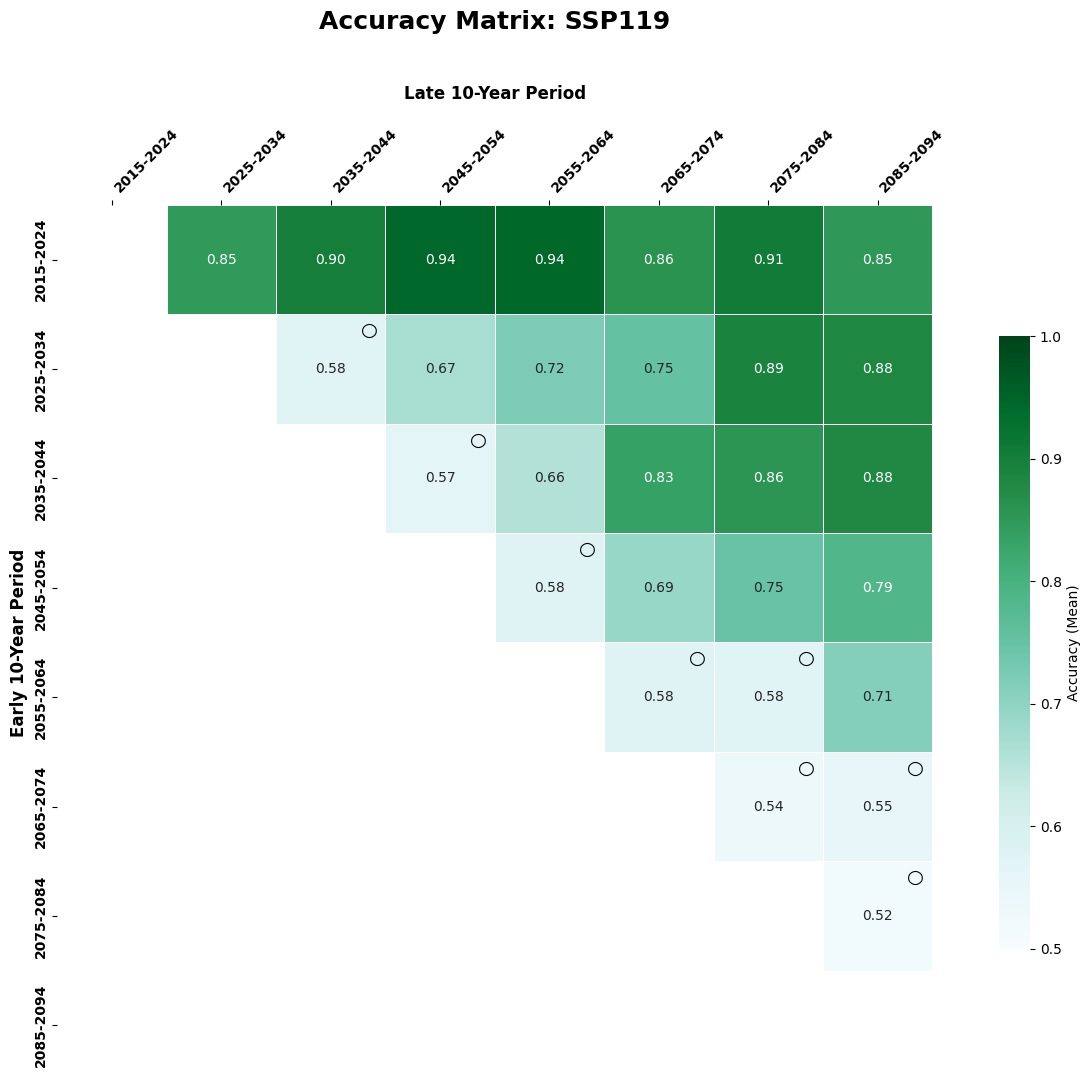

In [19]:
plot_unbinned_matrix(mean_std_119, scenario_id="ssp119")

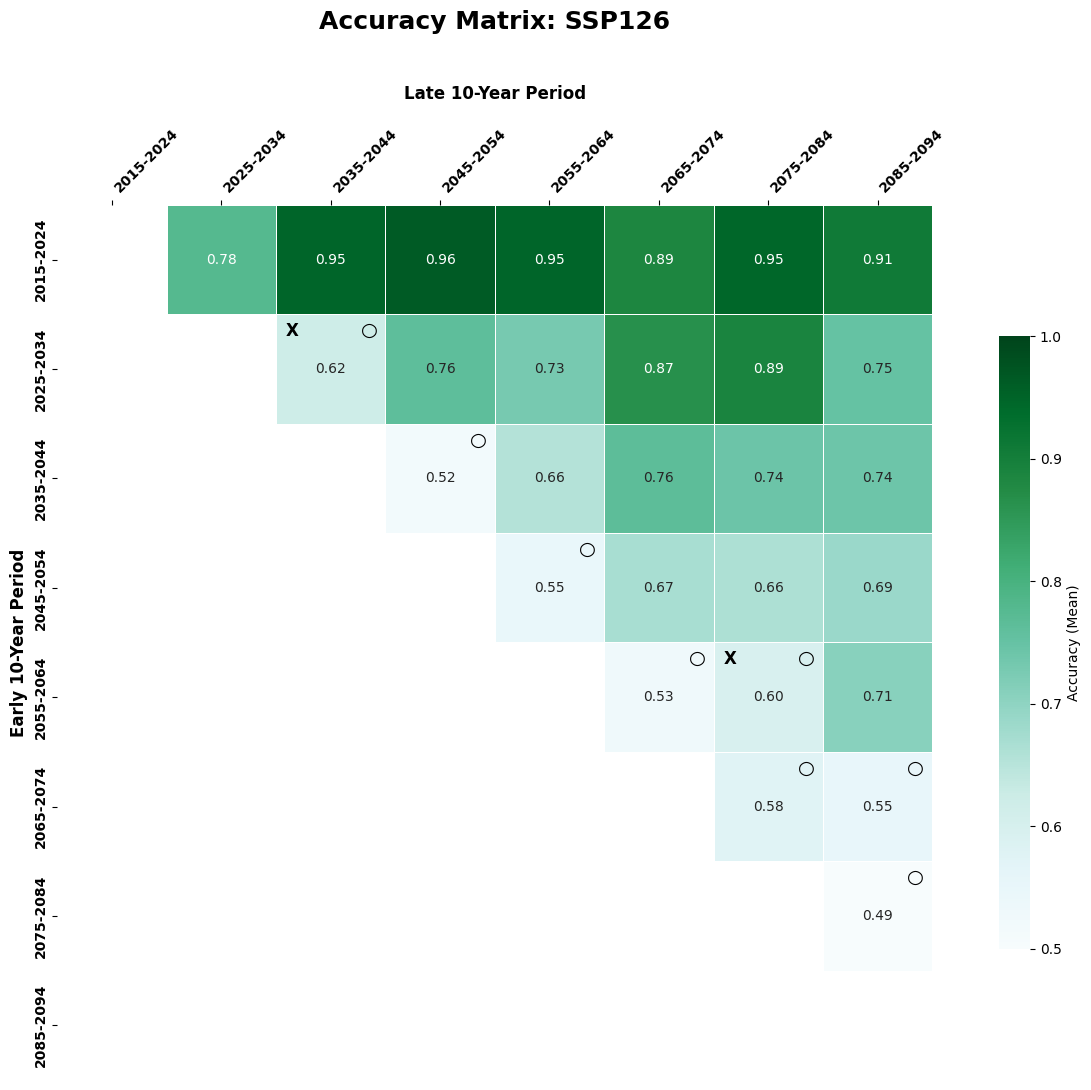

In [20]:
plot_unbinned_matrix(mean_std_126, scenario_id="ssp126")